In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nishantsingh96/refined-bookcorpus-dataset/BookCorpus3.csv


In [2]:
df = pd.read_csv(
    "/kaggle/input/datasets/nishantsingh96/refined-bookcorpus-dataset/BookCorpus3.csv",
    nrows=200000
)

In [3]:
df.columns

Index(['0'], dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   0       200000 non-null  object
dtypes: object(1)
memory usage: 1.5+ MB


In [5]:
df.head()

,0
0,she began getting up first thing in the mornin...
1,caitrin hid the fact that she was a woman behi...
2,"she considered strapping down her breasts, and..."
3,as hard as it had been for caitrin to convince...
4,"as her treks took her farther afield, she woul..."


### Convert the Dataset into One Long Text Corpus

In [6]:
text = "\n".join(df["0"].dropna().astype(str))

In [7]:
len(text)

88397287

In [8]:
type(text)

str

In [9]:
text[:500]

"she began getting up first thing in the morning. she wanted to avoid konnor and his irrational fear at having her leave him alone in the house. she'd fix a quick bite to eat for both of them, leave konnor's on the table, and then she went to dress for the day.\ncaitrin hid the fact that she was a woman behind bulky clothes. her jeans were loose. she tucked the cuffs into the expensive hiking boots she had obtained during a smash and grab at an outdoor store's window display.\nshe considered strapp"

### Build the Character Vocabulary

A neural network cannot process characters directly. It only works with numbers.

So the first step is to find every unique character that appears in the corpus.

In [10]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

In [11]:
f"Vocabulary Size: {vocab_size}"

'Vocabulary Size: 45'

In [12]:
chars[:20]

['\n',
 ' ',
 "'",
 '(',
 ')',
 ',',
 '.',
 '/',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '@',
 'a']

In [13]:
chars[-20:]

['g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

## Convert the Entire Corpus into Integer IDs

In [14]:
import torch

In [15]:
data = torch.tensor(
    [char_to_idx[c] for c in text],
    dtype=torch.long
)

In [16]:
type(data)

torch.Tensor

In [17]:
data.shape

torch.Size([88397287])

In [18]:
sample = text[:20]

print(sample)

she began getting up


In [19]:
print([char_to_idx[c] for c in sample])

[37, 26, 23, 1, 20, 23, 25, 19, 32, 1, 25, 23, 38, 38, 27, 32, 25, 1, 39, 34]


### Define the Hyperparameters

In [20]:
seq_len = 25
batch_size = 16

## Create the Batch Function

In [21]:
def get_batch():
    max_start = len(data) - seq_len - 1
    starts = torch.randint(0, max_start, (batch_size,))

    x = torch.stack([
        data[s:s + seq_len]
        for s in starts
    ])

    y = torch.stack([
        data[s + 1:s + seq_len + 1]
        for s in starts
    ])

    return x, y

In [22]:
x, y = get_batch()

print(x.shape)
print(y.shape)

torch.Size([16, 25])
torch.Size([16, 25])


In [23]:
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

## Vanilla RNN Model

In [24]:
class VanillaRNNLM(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        # Input → Hidden
        self.Wxh = nn.Parameter(
            torch.randn(vocab_size, hidden_size) * 0.01
        )

        # Hidden → Hidden (Recurrent)
        self.Whh = nn.Parameter(
            torch.randn(hidden_size, hidden_size) * 0.01
        )

        # Hidden → Output
        self.Why = nn.Parameter(
            torch.randn(hidden_size, vocab_size) * 0.01
        )

        self.bh = nn.Parameter(torch.zeros(hidden_size))
        self.by = nn.Parameter(torch.zeros(vocab_size))

    def forward(self, x, h_prev=None):

        batch, T = x.shape

        if h_prev is None:
            h_prev = torch.zeros(
                batch,
                self.hidden_size,
                device=x.device
            )

        x_onehot = F.one_hot(
            x,
            num_classes=self.vocab_size
        ).float()

        logits = []

        h = h_prev

        for t in range(T):

            x_t = x_onehot[:, t, :]

            h = torch.tanh(
                x_t @ self.Wxh +
                h @ self.Whh +
                self.bh
            )

            y_t = h @ self.Why + self.by

            logits.append(y_t)

        logits = torch.stack(logits, dim=1)

        return logits, h.detach()

## Text Generation Function

In [25]:
@torch.no_grad()
def generate(model, seed_str, length=200, temperature=0.8):

    model.eval()

    h = torch.zeros(1, model.hidden_size)

    idxs = [char_to_idx[c] for c in seed_str]

    # Warm-up hidden state
    for i in idxs[:-1]:

        x_t = F.one_hot(
            torch.tensor([i]),
            num_classes=vocab_size
        ).float()

        h = torch.tanh(
            x_t @ model.Wxh +
            h @ model.Whh +
            model.bh
        )

    current = idxs[-1]

    out_chars = list(seed_str)

    for _ in range(length):

        x_t = F.one_hot(
            torch.tensor([current]),
            num_classes=vocab_size
        ).float()

        h = torch.tanh(
            x_t @ model.Wxh +
            h @ model.Whh +
            model.bh
        )

        logits = h @ model.Why + model.by

        probs = F.softmax(
            logits / temperature,
            dim=-1
        ).squeeze()

        current = torch.multinomial(
            probs,
            num_samples=1
        ).item()

        out_chars.append(idx_to_char[current])

    model.train()

    return "".join(out_chars)

## Initialize Model

In [26]:
hidden_size = 128

model = VanillaRNNLM(
    vocab_size=vocab_size,
    hidden_size=hidden_size
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-3
)

## Training Loop

## Plot Training Loss

In [27]:
n_steps = 3000

loss_history = []

h_state = None

for step in range(n_steps):

    x, y = get_batch()

    logits, h_state = model(x, h_state)

    loss = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        y.reshape(-1)
    )

    optimizer.zero_grad()

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=5.0
    )

    optimizer.step()

    loss_history.append(loss.item())

    if step % 200 == 0 or step == n_steps - 1:

        print(f"Step {step:4d} | Loss: {loss.item():.4f}")

        print(
            generate(
                model,
                seed_str="she ",
                length=100,
                temperature=0.8
            )
        )

        print("-" * 80)

Step    0 | Loss: 3.8065
she 9z3ayjc7v1tnrvb),8e.ul 2/e8gn44hw2lf/mdrw@@301hvr.hm/qqa1..ay
g7s@cmw5b0kxxn7(iof a5cmxodqvxqz890ayz
--------------------------------------------------------------------------------
Step  200 | Loss: 2.6031
she fitunu be crei lhet lhpin n.lei nn ind theamot anete lmne. be  eled y can  ok odde at thetheowin  na
--------------------------------------------------------------------------------
Step  400 | Loss: 2.4061
she heure faone t aes aroul tieds thes po ser the theshing and anghe in out oralt ao tou isus at we au t
--------------------------------------------------------------------------------
Step  600 | Loss: 2.3441
she the cict sterighed tisher githr ind that ing the lochy on ay b'ed ois aystathe bolted surpentt iodss
--------------------------------------------------------------------------------
Step  800 | Loss: 2.2644
she flagst dissed bboulicures lo ke parg that and sshey ars fied filintotilly 1 ku marcouuns yon or banc
--------------------------

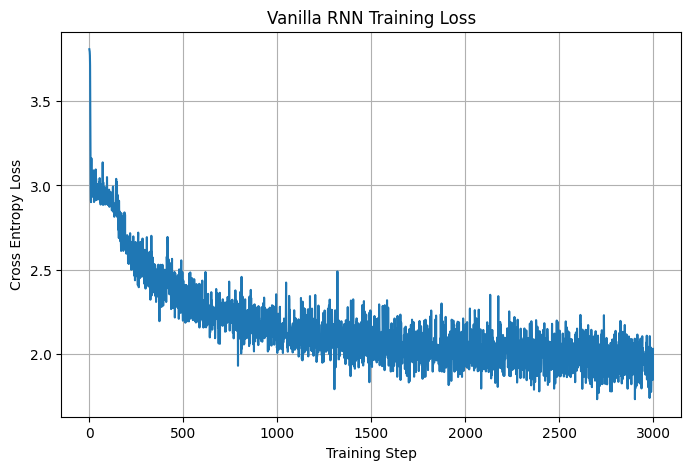

In [28]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Training Step")
plt.ylabel("Cross Entropy Loss")
plt.title("Vanilla RNN Training Loss")

plt.grid(True)

plt.show()

## Generate Final Text

In [29]:
print(generate(
    model,
    seed_str="she ",
    length=500,
    temperature=0.8
))

she dost dien back to serearly of in whatt angyinga probor goon gond and he had the can of the arsed of edentive to see than and . repentry had es an i was the ampered thand have conletained the had an every wate i could go hall of my eargen on procked in as sememple were pay see hese and wil say. reshing down quick as ene. was pirter and interbart and the eas in was sump bl corled the kidtion after of the west in the lasg and a saxps of the. renory of a a oghte a mar herever to the retack the palsm


## Conclusion

A Vanilla RNN was implemented from scratch using raw matrix operations for the recurrent computations, without using nn.RNN, nn.RNNCell, or nn.Linear in the recurrent core. The model was trained on a 200,000-row subset of the Refined BookCorpus dataset for character-level next-character prediction, reducing the cross-entropy loss from approximately 3.81 to 1.72 in 3,000 training steps. The generated samples evolved from random characters to coherent English-like text with recognizable words and sentence structure, demonstrating that the manually implemented recurrence successfully learned character-level language pattern